# Tiered KV H100 RunPod Drop-In

This notebook expects `runpod_h100_dropin/` and `tiered_kv/` to be sibling folders. It uses the bundled tuned policy config in `best_policy_config.json`. The default profile is `h100-safe`, which avoids the previous 32K perplexity OOM by testing perplexity up to 16K first.

In [1]:
# Setup. Run this first, then restart the kernel if packages were installed.
import os
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

%pip install -q -r requirements-runpod.txt

import sys
print('python:', sys.version)
print('CUDA_VISIBLE_DEVICES:', os.environ.get('CUDA_VISIBLE_DEVICES'))
print('PYTORCH_CUDA_ALLOC_CONF:', os.environ.get('PYTORCH_CUDA_ALLOC_CONF'))



[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
python: 3.11.10 (main, Sep  7 2024, 18:35:41) [GCC 11.4.0]
CUDA_VISIBLE_DEVICES: 0
PYTORCH_CUDA_ALLOC_CONF: expandable_segments:True


In [1]:
import json
import os
import sys
from pathlib import Path

import torch

DROPIN = Path.cwd().resolve()
PARENT = DROPIN.parent
for path in (DROPIN, PARENT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from run_h100_benchmark import get_profile, run_benchmark, resolve_policy_config, summarize

PROFILE_NAME = os.environ.get('PROFILE_NAME', 'h100-safe')
MODEL_ID = os.environ.get('MODEL_ID') or None
PROFILE = get_profile(PROFILE_NAME, model_id=MODEL_ID)
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
POLICY_CONFIG_FILE = Path(os.environ.get('POLICY_CONFIG_FILE', 'best_policy_config.json'))
if not POLICY_CONFIG_FILE.exists():
    raise FileNotFoundError(f'Missing policy config: {POLICY_CONFIG_FILE}')
POLICY_CONFIG = resolve_policy_config(json.loads(POLICY_CONFIG_FILE.read_text()))

print('dropin:', DROPIN)
print('sibling tiered_kv exists:', (PARENT / 'tiered_kv').exists())
print('profile:', PROFILE)
print('device:', DEVICE)
print('policy_config_file:', POLICY_CONFIG_FILE)
print(json.dumps(POLICY_CONFIG, indent=2))
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))


dropin: /workspace/runpod_h100_dropin
sibling tiered_kv exists: True
profile: BenchmarkProfile(name='h100-safe', model_id='Qwen/Qwen2.5-7B-Instruct', dtype='bfloat16', recall_lengths=(1024, 2048, 4096, 8192, 16384), recall_samples=5, recall_pairs=20, perplexity_lengths=(2048, 8192, 16384), max_scored_tokens=8000, memory_prompt_tokens=16000, throughput_new_tokens=64, throughput_iters=3, niah_lengths=(2000, 8000, 16000, 32000), niah_depths=(10, 30, 50, 70, 90))
device: cuda:0
policy_config_file: best_policy_config.json
{
  "tier_bits": [
    16,
    8,
    4,
    4
  ],
  "group_size": 64,
  "fixed": {
    "fp16": 256,
    "int8": 2048,
    "int4": 3072,
    "n_sink": 4
  },
  "ratio": {
    "fp16_pct": 0.12,
    "int8_pct": 0.25,
    "int4_pct": 0.55,
    "n_sink": 8,
    "min_fp16": 96
  },
  "hybrid": {
    "n_sink": 4,
    "fp16": 96,
    "geometric": true,
    "growth": 2.0,
    "int8": 256,
    "int4": 3072
  },
  "name": "random_0119"
}
gpu: NVIDIA H100 80GB HBM3


## Main Benchmark

Runs recall, perplexity, measured KV-cache memory, and throughput. Use a fresh kernel before rerunning this cell.

In [2]:
result = run_benchmark(
    PROFILE,
    device=DEVICE,
    policy_config=POLICY_CONFIG,
    run_recall=True,
    run_perplexity=True,
    run_niah=False,
    run_memory=True,
    output_dir=Path('results/runpod_h100'),
)
summary = summarize(result)
summary_path = Path(result['output_path']).with_name(Path(result['output_path']).stem + '_summary.json')
summary_path.write_text(json.dumps(summary, indent=2))
print('saved:', result.get('output_path'))
print('summary:', summary_path)
print(json.dumps(result['sanity'], indent=2))
print(json.dumps(summary, indent=2))


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

...

README.md: 0.00B [00:00, ?B/s]

pual_graham_essays.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/215 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


saved: results/runpod_h100/h100-safe_1777825568.json
summary: results/runpod_h100/h100-safe_1777825568_summary.json
{
  "quantizer": {
    "int8_max_abs_error": 0.0,
    "int4_max_abs_error": 0.0078125,
    "int2_max_abs_error": 0.0390625
  },
  "cache_passthrough": {
    "max_abs_logit_diff": 0.0,
    "mean_abs_logit_diff": 0.0,
    "tokens": 10
  }
}
{
  "recall": {
    "FP16 baseline": {
      "mean": 0.96,
      "retention": 1.0
    },
    "FixedWindow": {
      "mean": 0.64,
      "retention": 0.6666666666666667
    },
    "Ratio": {
      "mean": 0.36,
      "retention": 0.375
    },
    "Hybrid": {
      "mean": 0.44000000000000006,
      "retention": 0.4583333333333334
    }
  },
  "perplexity_ratio": {
    "FP16 baseline": {
      "mean": 1.0,
      "max": 1.0
    },
    "FixedWindow": {
      "mean": 5.261827836795212,
      "max": 10.87739334813893
    },
    "Ratio": {
      "mean": 10.288620170663105,
      "max": 23.86758329864462
    },
    "Hybrid": {
      "mean": 3.12

## Tables

In [3]:
import pandas as pd

recall_rows = []
for group in result.get('recall', []):
    for length, acc, ok, total in zip(group['lengths'], group['accuracy'], group['n_correct'], group['n_total']):
        recall_rows.append({'strategy': group['strategy'], 'context_len': length, 'accuracy': acc, 'n_correct': ok, 'n_total': total})
recall_df = pd.DataFrame(recall_rows)
display(recall_df)

ppl_rows = []
for group in result.get('perplexity', []):
    for row in group['rows']:
        ppl_rows.append({'strategy': group['strategy'], **row})
ppl_df = pd.DataFrame(ppl_rows)
display(ppl_df)

mem_df = pd.DataFrame(result.get('memory', []))
thru_df = pd.DataFrame(result.get('throughput', []))
if not mem_df.empty:
    baseline_bytes = float(mem_df.loc[mem_df['strategy'] == 'FP16 baseline', 'cache_bytes_empirical'].iloc[0])
    mem_df['cache_MB'] = mem_df['cache_bytes_empirical'] / 1e6
    mem_df['ratio_to_baseline'] = mem_df['cache_bytes_empirical'] / baseline_bytes
    display(mem_df[['strategy', 'seq_len', 'cache_MB', 'ratio_to_baseline', 'peak_alloc_bytes', 'peak_reserved_bytes']])
if not thru_df.empty:
    display(thru_df[['strategy', 'tokens_per_second', 'median_seconds', 'n_new_tokens']])


,strategy,context_len,accuracy,n_correct,n_total
0,FP16 baseline,1024,1.0,5,5
1,FP16 baseline,2048,1.0,5,5
2,FP16 baseline,4096,1.0,5,5
3,FP16 baseline,8192,1.0,5,5
4,FP16 baseline,16384,0.8,4,5
5,FixedWindow,1024,1.0,5,5
6,FixedWindow,2048,0.8,4,5
7,FixedWindow,4096,0.4,2,5
8,FixedWindow,8192,1.0,5,5
9,FixedWindow,16384,0.0,0,5


,strategy,context_len,perplexity,n_tokens_scored
0,FP16 baseline,2048,8.741120,10039
1,FP16 baseline,8192,8.674743,16189
2,FP16 baseline,16384,8.453223,24382
3,FixedWindow,2048,8.739446,10039
4,FixedWindow,8192,94.358588,16189
5,FixedWindow,16384,33.037576,24382
6,Ratio,2048,208.629421,10039
7,Ratio,8192,36.037808,16189
8,Ratio,16384,24.040456,24382
9,Hybrid,2048,59.866971,10039


,strategy,seq_len,cache_MB,ratio_to_baseline,peak_alloc_bytes,peak_reserved_bytes
0,FP16 baseline,16000,917.504000,1.000000,21210338816,24173871104
1,FixedWindow,16000,298.156544,0.324965,20592297472,23370661888
2,Ratio,16000,395.666432,0.431242,20704441856,23265804288
3,Hybrid,16000,265.212416,0.289059,20557764096,23267901440


,strategy,tokens_per_second,median_seconds,n_new_tokens
0,FP16 baseline,33.484517,1.911331,64
1,FixedWindow,10.957515,5.840740,64
2,Ratio,16.479330,3.883653,64
3,Hybrid,10.928147,5.856436,64


## Plots

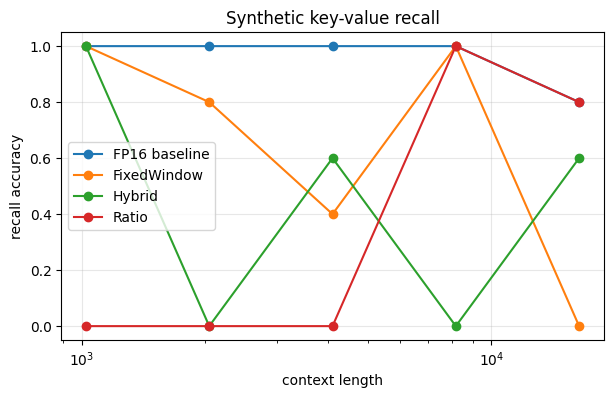

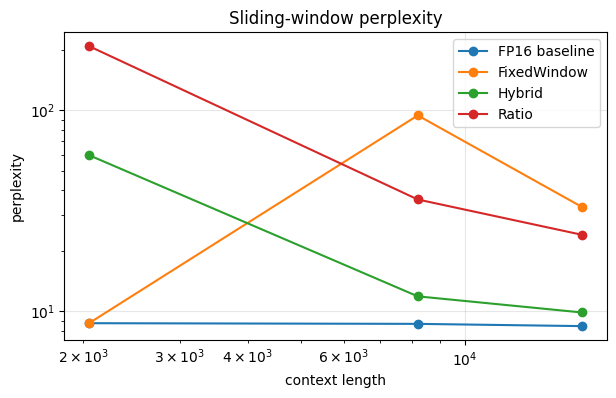

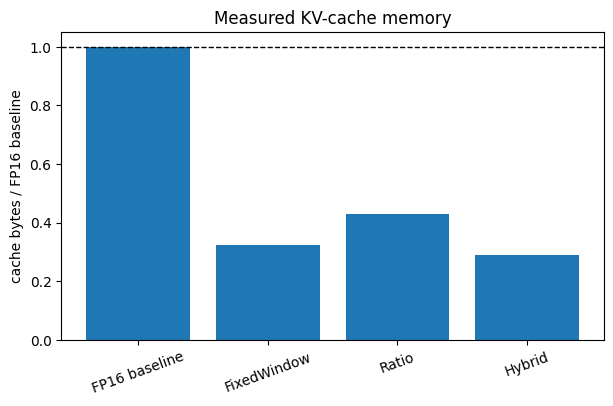

In [4]:
import matplotlib.pyplot as plt

if not recall_df.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    for name, g in recall_df.groupby('strategy'):
        ax.plot(g['context_len'], g['accuracy'], marker='o', label=name)
    ax.set_xscale('log')
    ax.set_xlabel('context length')
    ax.set_ylabel('recall accuracy')
    ax.set_title('Synthetic key-value recall')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

if not ppl_df.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    for name, g in ppl_df.groupby('strategy'):
        ax.plot(g['context_len'], g['perplexity'], marker='o', label=name)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('context length')
    ax.set_ylabel('perplexity')
    ax.set_title('Sliding-window perplexity')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

if not mem_df.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(mem_df['strategy'], mem_df['ratio_to_baseline'])
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('cache bytes / FP16 baseline')
    ax.set_title('Measured KV-cache memory')
    ax.tick_params(axis='x', rotation=20)
    plt.show()


## Optional NIAH

Run this after the main benchmark, preferably from a fresh kernel if memory is tight.

In [6]:
# Uncomment to run NIAH only.
import torch
torch.cuda.empty_cache()
niah_result = run_benchmark(
    PROFILE,
    device=DEVICE,
    policy_config=POLICY_CONFIG,
    run_recall=False,
    run_perplexity=False,
    run_niah=True,
    run_memory=False,
    output_dir=Path('results/runpod_h100_niah'),
)
niah_summary = summarize(niah_result)
print(niah_result.get('output_path'))
print(json.dumps(niah_summary, indent=2))


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


results/runpod_h100_niah/h100-safe_1777826002.json
{
  "recall": {},
  "perplexity_ratio": {},
  "memory": {},
  "throughput": {},
  "niah": {
    "FP16 baseline": {
      "accuracy": 1.0,
      "correct": 20,
      "total": 20
    },
    "FixedWindow": {
      "accuracy": 0.85,
      "correct": 17,
      "total": 20
    },
    "Ratio": {
      "accuracy": 0.65,
      "correct": 13,
      "total": 20
    },
    "Hybrid": {
      "accuracy": 0.9,
      "correct": 18,
      "total": 20
    }
  }
}
